# Data visualization

**Prompt**: Please provide me a keras code segment to visualize the data (showing some same-category and different-category samples and with labels) in cifar10.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1263s 7us/step


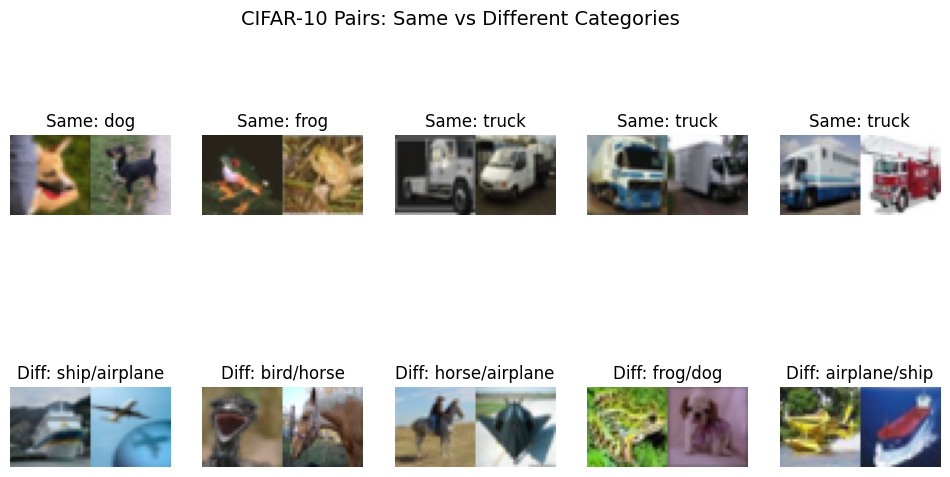

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import cifar10

# -----------------------------
# Load CIFAR-10
# -----------------------------
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train, y_test = y_train.flatten(), y_test.flatten()

# CIFAR-10 class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# -----------------------------
# Helper function: pick random same/different pairs
# -----------------------------
def get_pairs(x, y, n=5):
    same_pairs = []
    diff_pairs = []
    n_classes = np.max(y) + 1
    digit_indices = [np.where(y == i)[0] for i in range(n_classes)]

    for _ in range(n):
        # same category
        c = np.random.randint(0, n_classes)
        i1, i2 = np.random.choice(digit_indices[c], 2, replace=False)
        same_pairs.append((x[i1], x[i2], y[i1]))

        # different category
        c1, c2 = np.random.choice(n_classes, 2, replace=False)
        i1 = np.random.choice(digit_indices[c1])
        i2 = np.random.choice(digit_indices[c2])
        diff_pairs.append((x[i1], x[i2], (y[i1], y[i2])))

    return same_pairs, diff_pairs

same_pairs, diff_pairs = get_pairs(x_train, y_train, n=5)

# -----------------------------
# Visualization
# -----------------------------
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, (img1, img2, label) in enumerate(same_pairs):
    axes[0, i].imshow(np.hstack([img1, img2]))
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Same: {class_names[label]}")

for i, (img1, img2, labels) in enumerate(diff_pairs):
    axes[1, i].imshow(np.hstack([img1, img2]))
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Diff: {class_names[labels[0]]}/{class_names[labels[1]]}")

plt.suptitle("CIFAR-10 Pairs: Same vs Different Categories", fontsize=14)
plt.show()


# Data pair preparation, training and test
**Prompt**: I have loaded the CIFAR-10 data using the previous code segment. Please provide me a Keras functional API code segment to train and test the shared dual-input-CNN network using CIFAR-10.

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import numpy as np

# -----------------------------
# Helper: Create training/testing pairs
# -----------------------------
def create_pairs(x, y, num_pairs=30000):
    pairs = []
    labels = []
    n_classes = np.max(y) + 1
    digit_indices = [np.where(y == i)[0] for i in range(n_classes)]

    for _ in range(num_pairs):
        # Positive pair (same category)
        c = np.random.randint(0, n_classes)
        i1, i2 = np.random.choice(digit_indices[c], 2, replace=False)
        pairs.append([x[i1], x[i2]])
        labels.append(1)

        # Negative pair (different category)
        c1, c2 = np.random.choice(n_classes, 2, replace=False)
        i1 = np.random.choice(digit_indices[c1])
        i2 = np.random.choice(digit_indices[c2])
        pairs.append([x[i1], x[i2]])
        labels.append(0)

    return np.array(pairs), np.array(labels)

train_pairs, train_labels = create_pairs(x_train, y_train, num_pairs=30000)
test_pairs, test_labels = create_pairs(x_test, y_test, num_pairs=5000)

# -----------------------------
# Build shared CNN feature extractor
# -----------------------------
def build_base_cnn(input_shape=(32, 32, 3)):
    inp = Input(shape=input_shape)
    x = layers.Conv2D(4, (3,3), activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(8, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(16, (3,3), activation="relu", padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    return Model(inp, x, name="feature_extractor")

base_cnn = build_base_cnn()

# -----------------------------
# Dual-input Siamese model
# -----------------------------
input_a = Input(shape=(32, 32, 3))
input_b = Input(shape=(32, 32, 3))

feat_a = base_cnn(input_a)
feat_b = base_cnn(input_b)

# Compare embeddings (absolute difference and dot product)
diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]))([feat_a, feat_b])
cos = layers.Dot(axes=1, normalize=True)([feat_a, feat_b])
#combined = diff
combined = cos

x = layers.Dense(128, activation="relu")(combined)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation="sigmoid")(x)

model = Model([input_a, input_b], output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

# -----------------------------
# Train model
# -----------------------------
history = model.fit(
    [train_pairs[:,0], train_pairs[:,1]], train_labels,
    validation_data=([test_pairs[:,0], test_pairs[:,1]], test_labels),
    batch_size=128,
    epochs=4
)

# -----------------------------
# Evaluate on test set
# -----------------------------
loss, acc = model.evaluate([test_pairs[:,0], test_pairs[:,1]], test_labels, verbose=0)
print(f"Test Accuracy: {acc:.4f}")


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_17      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_extractor   │ (None, 128)       │    132,776 │ input_layer_16[0… │
│ (Functional)        │                   │            │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ feature_extracto… │
│                     │                   │            │ feature_extracto… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 128)       │        256 │ dot[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1)         │        129 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 133,161 (520.16 KB)

 Trainable params: 133,161 (520.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 149ms/step - accuracy: 0.5492 - loss: 0.6855 - val_accuracy: 0.5751 - val_loss: 0.6786
Epoch 2/4
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 145ms/step - accuracy: 0.6362 - loss: 0.6397 - val_accuracy: 0.6687 - val_loss: 0.6082
Epoch 3/4
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 145ms/step - accuracy: 0.6818 - loss: 0.5929 - val_accuracy: 0.6779 - val_loss: 0.5994
Epoch 4/4
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 145ms/step - accuracy: 0.7062 - loss: 0.5652 - val_accuracy: 0.6793 - val_loss: 0.5884
Test Accuracy: 0.6793


In [5]:
print(np.bincount(train_labels))
print(np.bincount(test_labels))

[30000 30000]
[5000 5000]


# Visualization in test sample pairs
**Prompt**: Please provide me a keras code sample to predict the same or different classification. Please show the image pair input and the ground truth label of each test sample pair.

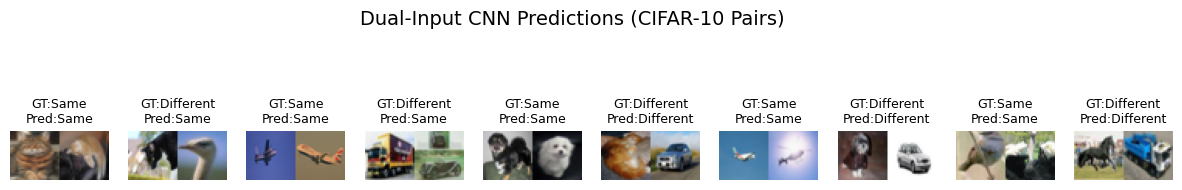

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Pick N test pairs
# -----------------------------
n_samples = 10
sample_pairs = test_pairs[:n_samples]
sample_labels = test_labels[:n_samples]

# -----------------------------
# Make predictions
# -----------------------------
pred_probs = model.predict([sample_pairs[:,0], sample_pairs[:,1]], verbose=0)
pred_labels = (pred_probs > 0.5).astype("int32").flatten()

# -----------------------------
# Plot image pairs with labels
# -----------------------------
plt.figure(figsize=(15, 3))
for i in range(n_samples):
    img1, img2 = sample_pairs[i]
    true_label = "Same" if sample_labels[i] == 1 else "Different"
    pred_label = "Same" if pred_labels[i] == 1 else "Different"

    plt.subplot(1, n_samples, i+1)
    plt.imshow(np.hstack([img1, img2]))
    plt.axis("off")
    plt.title(f"GT:{true_label}\nPred:{pred_label}", fontsize=9)

plt.suptitle("Dual-Input CNN Predictions (CIFAR-10 Pairs)", fontsize=14)
plt.show()
